[INFO] Input CSV: dfm_for_lme4_final_with_drowsy_fixed900ms.csv
[INFO] Rows after basic exclusion: 14,561

[INFO] Subjects qualifying per panel:
  A (congruency):  42
  B (cueType):     42
  C (EAR base):    42
  D (EAR SD):      42
  Common pool:     42

[INFO] Rows in df (common subjects):     14,561
[INFO] Rows in df_clean (common subjects): 14,561


/tmp/ipykernel_600203/1427743942.py:68: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series(assign_state(g), index=g.index))
/tmp/ipykernel_600203/1427743942.py:68: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series(assign_state(g), index=g.index))
/tmp/ipykernel_600203/1427743942.py:68: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. T

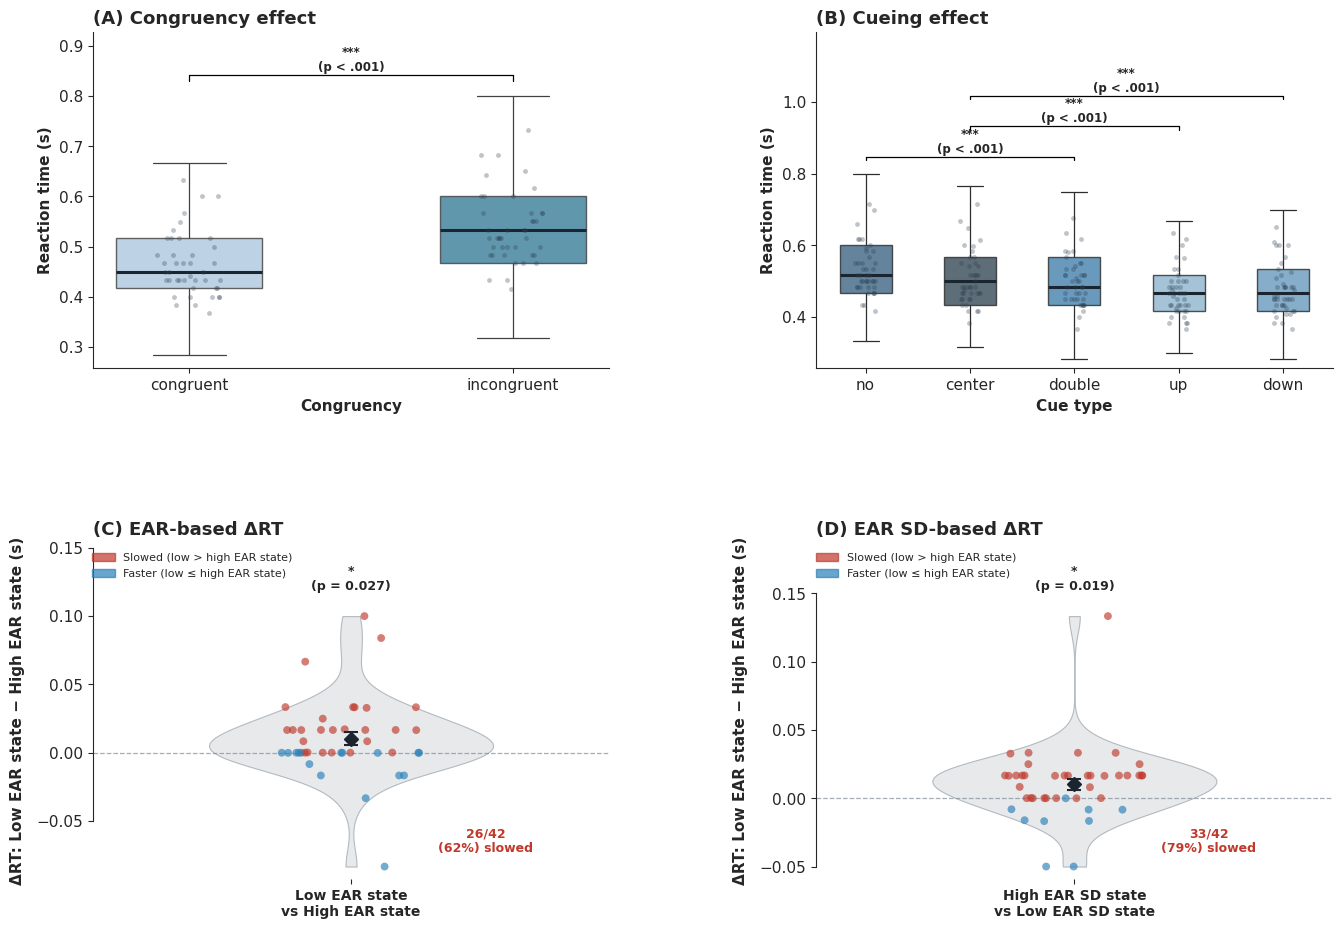

Figures A, B, C saved.


In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Arial", "Helvetica", "DejaVu Sans"]
plt.rcParams["font.size"] = 11
plt.rcParams["axes.linewidth"] = 0.8
plt.rcParams["xtick.major.width"] = 0.8
plt.rcParams["ytick.major.width"] = 0.8
sns.set_style("ticks")

# Load data
exclude_subjects = [1013, 1025, 1032, 1038, 1053, 1061, 1063, 1077]

main_csv = "dfm_for_lme4_final_with_drowsy_fixed900ms.csv"
if not os.path.exists(main_csv):
    main_csv = "dfm_for_lme4_final_with_drowsy.csv"

df_raw = pd.read_csv(main_csv)
df_raw = df_raw[~df_raw["subject_id"].isin(exclude_subjects)].copy()

for c in ["false_response_count", "trial_ear_success_frame_count", "response_time"]:
    if c in df_raw.columns:
        df_raw[c] = pd.to_numeric(df_raw[c], errors="coerce")
    else:
        raise ValueError(f"'{c}' 컬럼이 없습니다: {main_csv}")

df_raw = df_raw[
    (df_raw["false_response_count"] == 0) &
    (df_raw["trial_ear_success_frame_count"] > 0)
].copy()

df_ear = df_raw.dropna(
    subset=["trial_ear_norm_baseline", "trial_ear_norm_baseline_sd", "response_time"]
).copy()
df_ear = df_ear[df_ear["response_time"] > 0].copy()

print(f"[INFO] Input CSV: {main_csv}")
print(f"[INFO] Rows after basic exclusion: {len(df_raw):,}")


# 2. Common subject pool
MIN_TRIALS = 5

def _assign_ear_states(data, metric_col, is_higher_drowsy):
    df_plot = data.copy()

    def assign_state(grp):
        q_low = grp[metric_col].quantile(0.25)
        q_high = grp[metric_col].quantile(0.75)
        if is_higher_drowsy:
            cond_alert = grp[metric_col] <= q_low
            cond_drowsy = grp[metric_col] >= q_high
        else:
            cond_alert = grp[metric_col] >= q_high
            cond_drowsy = grp[metric_col] <= q_low
        return np.select([cond_alert, cond_drowsy], ["Alert", "Drowsy"], default="Middle")

    df_plot["State_Group"] = (
        df_plot.groupby("subject_id", group_keys=False)
        .apply(lambda g: pd.Series(assign_state(g), index=g.index))
    )
    return df_plot

def subjects_with_min_trials(data, group_col, conditions, min_n=MIN_TRIALS):
    """group_col의 각 condition에서 min_n 이상 trial을 가진 subject 반환"""
    counts = (
        data.groupby(["subject_id", group_col])["response_time"]
        .count()
        .reset_index()
        .rename(columns={"response_time": "n"})
    )
    valid = set(data["subject_id"].unique())
    for cond in conditions:
        cond_counts = counts[counts[group_col] == cond]
        qualified = set(cond_counts[cond_counts["n"] >= min_n]["subject_id"])
        valid = valid & qualified
    return valid

def subjects_ear_min_trials(data, metric_col, is_higher_drowsy, min_n=MIN_TRIALS):
    df_plot = _assign_ear_states(data, metric_col, is_higher_drowsy)
    df_compare = df_plot[df_plot["State_Group"] != "Middle"].copy()

    counts = (
        df_compare.groupby(["subject_id", "State_Group"])["response_time"]
        .count().reset_index()
        .rename(columns={"response_time": "n"})
    )
    valid = set(df_plot["subject_id"].unique())
    for state in ["Alert", "Drowsy"]:
        qualified = set(counts[(counts["State_Group"] == state) & (counts["n"] >= min_n)]["subject_id"])
        valid = valid & qualified
    return valid


# Panel A: congruent / incongruent
subj_A = subjects_with_min_trials(df_raw, "congruency", ["congruent", "incongruent"])

# Panel B: no, center, double, up, down
subj_B = subjects_with_min_trials(df_raw, "cueType", ["no", "center", "double", "up", "down"])

# Panel C: Low EAR (bottom 25%) vs High EAR (top 25%)
subj_C = subjects_ear_min_trials(df_ear, "trial_ear_norm_baseline", is_higher_drowsy=False)

# Panel D: Low EAR SD (bottom 25%) vs High EAR SD (top 25%)
subj_D = subjects_ear_min_trials(df_ear, "trial_ear_norm_baseline_sd", is_higher_drowsy=True)

common_subjects = subj_A & subj_B & subj_C & subj_D

print(f"\n[INFO] Subjects qualifying per panel:")
print(f"  A (congruency):  {len(subj_A)}")
print(f"  B (cueType):     {len(subj_B)}")
print(f"  C (EAR base):    {len(subj_C)}")
print(f"  D (EAR SD):      {len(subj_D)}")
print(f"  Common pool:     {len(common_subjects)}")

# common subjects
df       = df_raw[df_raw["subject_id"].isin(common_subjects)].copy()
df_clean = df_ear[df_ear["subject_id"].isin(common_subjects)].copy()

print(f"\n[INFO] Rows in df (common subjects):     {len(df):,}")
print(f"[INFO] Rows in df_clean (common subjects): {len(df_clean):,}")

# ---------------------------------------------------------
# Helpers
# ---------------------------------------------------------
def sig_stars(p):
    if p < 0.001: return "***"
    elif p < 0.01: return "**"
    elif p < 0.05: return "*"
    else: return "n.s."

def p_label(p):
    return "p < .001" if p < 0.001 else f"p = {p:.3f}"

def add_bracket(ax, x1, x2, y, p, y_range):
    h = y_range * 0.018
    ax.plot([x1, x1, x2, x2], [y, y + h, y + h, y], lw=0.9, color="black")
    stars = sig_stars(p)
    txt = f"{stars}\n({p_label(p)})" if stars != "n.s." else "n.s."
    ax.text((x1 + x2) / 2, y + h * 1.3, txt, ha="center", va="bottom",
            fontsize=8.5, fontweight="bold")

# ---------------------------------------------------------
# Plot A: Congruency
# ---------------------------------------------------------
def plot_congruency(ax, data):
    cong_order = [c for c in ["congruent", "incongruent"] if c in data["congruency"].unique()]
    palette = {"congruent": "#A8C8E8", "incongruent": "#2E86AB"}

    sns.boxplot(
        data=data, x="congruency", y="response_time", order=cong_order,
        hue="congruency", palette=palette, ax=ax,
        showfliers=False, linewidth=1.0, width=0.45, legend=False,
        boxprops=dict(alpha=0.82),
        medianprops=dict(color="#1A252F", linewidth=2.2),
        whiskerprops=dict(linewidth=0.9),
        capprops=dict(linewidth=0.9),
    )

    subj_med = data.groupby(["subject_id", "congruency"])["response_time"].median().reset_index()
    sns.stripplot(
        data=subj_med, x="congruency", y="response_time", order=cong_order,
        color="#2C3E50", alpha=0.3, size=3.5, ax=ax, jitter=True, zorder=5
    )

    pivot = subj_med.pivot(index="subject_id", columns="congruency", values="response_time").dropna()
    if all(c in pivot.columns for c in cong_order):
        _, p = stats.ttest_rel(pivot[cong_order[0]], pivot[cong_order[1]])
        ylo, yhi = ax.get_ylim()
        y_range = yhi - ylo
        add_bracket(ax, 0, 1, yhi + y_range * 0.01, p, y_range)
        ax.set_ylim(ylo, yhi + y_range * 0.18)

    ax.set_title("(A) Congruency effect", fontweight="bold", loc="left", fontsize=13)
    ax.set_ylabel("Reaction time (s)", fontweight="bold")
    ax.set_xlabel("Congruency", fontweight="bold")
    sns.despine(ax=ax)

# ---------------------------------------------------------
# Plot B: Cueing
# ---------------------------------------------------------
def plot_cueing(ax, data):
    cue_order = [c for c in ["no", "center", "double", "up", "down"] if c in data["cueType"].unique()]
    palette = sns.color_palette("Blues_d", len(cue_order))[::-1]

    sns.boxplot(
        data=data, x="cueType", y="response_time", order=cue_order,
        hue="cueType", palette=palette, ax=ax,
        showfliers=False, linewidth=1.0, width=0.5, legend=False,
        boxprops=dict(alpha=0.82),
        medianprops=dict(color="#1A252F", linewidth=2.2),
        whiskerprops=dict(linewidth=0.9),
        capprops=dict(linewidth=0.9),
    )

    subj_med = data.groupby(["subject_id", "cueType"])["response_time"].median().reset_index()
    sns.stripplot(
        data=subj_med, x="cueType", y="response_time", order=cue_order,
        color="#2C3E50", alpha=0.3, size=3.5, ax=ax, jitter=True, zorder=5
    )

    pivot = subj_med.pivot(index="subject_id", columns="cueType", values="response_time").dropna()
    ylo, yhi = ax.get_ylim()
    y_range = yhi - ylo

    comparisons = [("no", "double"), ("center", "up"), ("center", "down")]
    bracket_step = y_range * 0.15
    n_brackets = 0
    for c1, c2 in comparisons:
        if c1 not in pivot.columns or c2 not in pivot.columns:
            continue
        if c1 not in cue_order or c2 not in cue_order:
            continue
        _, p = stats.ttest_rel(pivot[c1], pivot[c2])
        x1, x2 = cue_order.index(c1), cue_order.index(c2)
        y_pos = yhi + y_range * 0.02 + n_brackets * bracket_step
        add_bracket(ax, x1, x2, y_pos, p, y_range)
        n_brackets += 1

    ax.set_ylim(ylo, yhi + y_range * 0.08 + n_brackets * bracket_step + y_range * 0.12)
    ax.set_title("(B) Cueing effect", fontweight="bold", loc="left", fontsize=13)
    ax.set_ylabel("Reaction time (s)", fontweight="bold")
    ax.set_xlabel("Cue type", fontweight="bold")
    sns.despine(ax=ax)

# ---------------------------------------------------------
# Plot C/D: Paired-difference violin
# ---------------------------------------------------------
def compute_paired_diff(data, metric_col, is_higher_drowsy):
    df_plot = _assign_ear_states(data, metric_col, is_higher_drowsy)
    df_compare = df_plot[df_plot["State_Group"] != "Middle"].copy()

    summary_df = (
        df_compare.groupby(["subject_id", "State_Group"])["response_time"]
        .agg(["median", "count"]).reset_index()
    )
    pivot_val = summary_df.pivot(index="subject_id", columns="State_Group", values="median").dropna()
    pivot_count = summary_df.pivot(index="subject_id", columns="State_Group", values="count").dropna()
    pivot_count.columns = ["Alert_N", "Drowsy_N"]

    plot_data = pd.concat([pivot_val[["Alert", "Drowsy"]], pivot_count], axis=1)
    plot_data["diff"] = plot_data["Drowsy"] - plot_data["Alert"]
    return plot_data


def plot_ear_violin(ax, data, metric_col, is_higher_drowsy, xlabel, panel_title, ylabel):
    np.random.seed(42)
    plot_data = compute_paired_diff(data, metric_col, is_higher_drowsy)

    if len(plot_data) < 3:
        ax.text(0.5, 0.5, "Not enough paired data", transform=ax.transAxes, ha="center", va="center")
        ax.axis("off")
        return

    diffs = plot_data["diff"].values

    parts = ax.violinplot(diffs, positions=[0], showmedians=False, showextrema=False, widths=0.55)
    for pc in parts["bodies"]:
        pc.set_facecolor("#D5D8DC")
        pc.set_edgecolor("#808B96")
        pc.set_alpha(0.55)
        pc.set_linewidth(0.8)

    jitter = np.random.uniform(-0.14, 0.14, size=len(diffs))
    colors = ["#C0392B" if d > 0 else "#2980B9" for d in diffs]
    for d, jit, col in zip(diffs, jitter, colors):
        ax.scatter(jit, d, color=col, alpha=0.65, s=32, zorder=3, edgecolors="none")

    mean_diff = np.mean(diffs)
    sem_diff = stats.sem(diffs)
    ax.errorbar(0, mean_diff, yerr=sem_diff, fmt="D", color="#1A252F",
                markersize=7, capsize=5, capthick=1.5, linewidth=1.8, zorder=6, label="Mean ± SEM")

    ax.axhline(0, color="#808B96", linestyle="--", linewidth=0.9, alpha=0.7)

    _, p = stats.ttest_1samp(diffs, 0)
    stars = sig_stars(p)
    txt = f"{stars}\n({p_label(p)})"
    ylo, yhi = ax.get_ylim()
    y_range = yhi - ylo
    ax.text(0, yhi + y_range * 0.04, txt, ha="center", va="bottom", fontsize=9, fontweight="bold")
    ax.set_ylim(ylo, yhi + y_range * 0.22)

    n_slowed = (diffs > 0).sum()
    n_total = len(diffs)
    pct = n_slowed / n_total * 100
    ax.text(0.76, 0.08, f"{n_slowed}/{n_total}\n({pct:.0f}%) slowed",
            transform=ax.transAxes, ha="center", fontsize=9, color="#C0392B", fontweight="bold")

    from matplotlib.patches import Patch
    legend_handles = [
        Patch(color="#C0392B", alpha=0.7, label="Slowed (low > high EAR state)"),
        Patch(color="#2980B9", alpha=0.7, label="Faster (low ≤ high EAR state)"),
    ]
    ax.legend(handles=legend_handles, fontsize=8, frameon=False,
              loc="upper left", bbox_to_anchor=(-0.02, 1.0))

    ax.set_xticks([0])
    ax.set_xticklabels([xlabel], fontweight="bold", fontsize=10)
    ax.set_ylabel("ΔRT: Low EAR state − High EAR state (s)", fontweight="bold", labelpad=8)
    ax.set_xlim(-0.5, 0.5)
    ax.set_title(panel_title, fontweight="bold", loc="left", fontsize=13)

    sns.despine(ax=ax, trim=True)


# ---------------------------------------------------------
# 2×2 Figure
# ---------------------------------------------------------
fig = plt.figure(figsize=(16, 11))
gs = fig.add_gridspec(2, 2, wspace=0.40, hspace=0.52)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, 0])
ax4 = fig.add_subplot(gs[1, 1])

plot_congruency(ax1, df)
plot_cueing(ax2, df)

# fig.text(0.06, 0.49, "(C) EAR-based ΔRT  (Drowsy − Alert, per participant)",
#          fontweight="bold", fontsize=13)

plot_ear_violin(
    ax3, df_clean, "trial_ear_norm_baseline", is_higher_drowsy=False,
    xlabel="Low EAR state\nvs High EAR state",
    panel_title="(C) EAR-based ΔRT",
    ylabel="ΔRT: Bottom 25% − Top 25% EAR (s)"
)
plot_ear_violin(
    ax4, df_clean, "trial_ear_norm_baseline_sd", is_higher_drowsy=True,
    xlabel="High EAR SD state\nvs Low EAR SD state",
    panel_title="(D) EAR SD-based ΔRT",
    ylabel="ΔRT: Top 25% − Bottom 25% EAR SD (s)"
)

plt.savefig("combined_figure_A_to_C_.png", dpi=600, bbox_inches="tight")
plt.savefig("combined_figure_A_to_C_.pdf", bbox_inches="tight")
plt.show()
plt.close()

print("Figures A, B, C saved.")


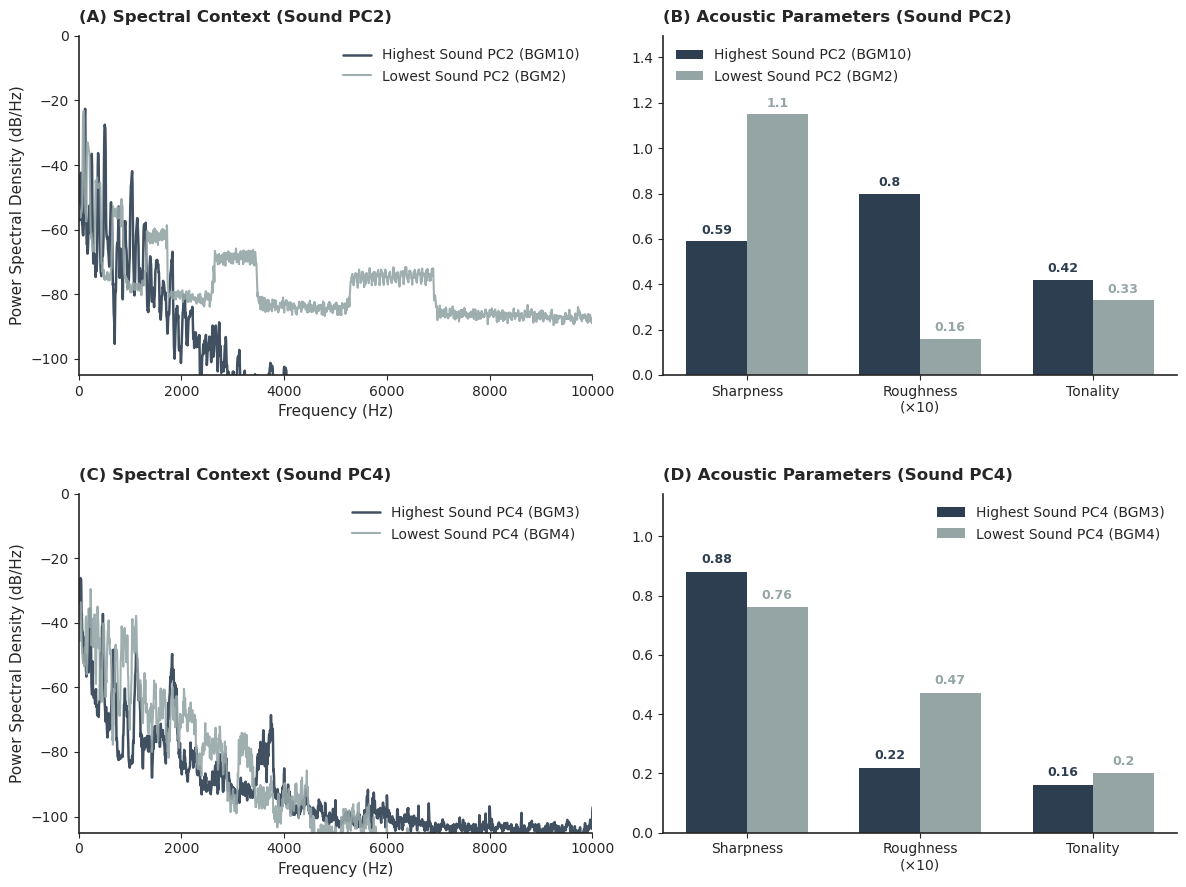

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile
from scipy.signal import welch

plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'axes.labelsize': 11,
    'axes.titlesize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'axes.linewidth': 1.2,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'patch.linewidth': 1.2,
})

# ---------------------------------------------------------
# 1. Data Setup
# ---------------------------------------------------------
# Provided Acoustic Parameters for the Extreme BGMs
params = {
    'bgm2': {'Sharpness': 1.15, 'Roughness': 0.016, 'Tonality': 0.33},
    'bgm3': {'Sharpness': 0.88, 'Roughness': 0.022, 'Tonality': 0.16},
    'bgm4': {'Sharpness': 0.76, 'Roughness': 0.047, 'Tonality': 0.20},
    'bgm10': {'Sharpness': 0.59, 'Roughness': 0.08, 'Tonality': 0.42}
}

file_bgm2 = '/users/kcl/data/ES/driving_sound/bgm2.wav'
file_bgm3 = '/users/kcl/data/ES/driving_sound/bgm3.wav'
file_bgm4 = '/users/kcl/data/ES/driving_sound/bgm4.wav'
file_bgm10 = '/users/kcl/data/ES/driving_sound/bgm10.wav'

c_high = '#2C3E50'
c_low = '#95A5A6'  

# ---------------------------------------------------------
# 2. Signal Processing (Spectrum Only)
# ---------------------------------------------------------
def get_psd(file_path):
    try:
        sr, data = wavfile.read(file_path)
        if len(data.shape) > 1: data = data.mean(axis=1) # Convert to mono
        data = data / np.max(np.abs(data))
        freqs, psd = welch(data, sr, nperseg=8192)
        return freqs, 10 * np.log10(psd)
    except Exception as e:
        print(f"File not found: {file_path}")
        return np.linspace(0, 22050, 4097), np.zeros(4097)-100

freqs2, psd2 = get_psd(file_bgm2)
freqs3, psd3 = get_psd(file_bgm3)
freqs4, psd4 = get_psd(file_bgm4)
freqs10, psd10 = get_psd(file_bgm10)

# ---------------------------------------------------------
# 3. Visualization Setup (2 Rows x 2 Columns)
# ---------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
# fig.suptitle("Descriptive Acoustic Profiles of Representative Sounds", fontweight='bold', fontsize=16, y=1.02)

labels = ['Sharpness', 'Roughness\n(×10)', 'Tonality']
x = np.arange(len(labels))
w = 0.35

# =========================================================
# ROW 1: PC2 (Negative/Tedious)
# =========================================================

# --- (A) Spectral Energy Distribution (PC2) ---
ax = axes[0, 0]
ax.plot(freqs10, psd10, color=c_high, label='Highest Sound PC2 (BGM10)', linewidth=1.8, alpha=0.9)
ax.plot(freqs2, psd2, color=c_low, label='Lowest Sound PC2 (BGM2)', linewidth=1.5, alpha=0.9)
ax.set_xlim(0, 10000) # PC4와 동일하게 범위를 맞춰 깔끔하게 정렬
ax.set_ylim(-105, 0)
ax.set_xlabel('Frequency (Hz)')
ax.set_ylabel('Power Spectral Density (dB/Hz)')
ax.set_title('(A) Spectral Context (Sound PC2)', loc='left', fontweight='bold', pad=10)
ax.legend(frameon=False)

# --- (B) Direct Parameter Comparison (PC2) ---
ax = axes[0, 1]
v_10 = [params['bgm10']['Sharpness'], params['bgm10']['Roughness']*10, params['bgm10']['Tonality']]
v_2 = [params['bgm2']['Sharpness'], params['bgm2']['Roughness']*10, params['bgm2']['Tonality']]

ax.bar(x - w/2, v_10, w, color=c_high, edgecolor='none', label='Highest Sound PC2 (BGM10)')
ax.bar(x + w/2, v_2, w, color=c_low, edgecolor='none', label='Lowest Sound PC2 (BGM2)')

for i in range(3):
    ax.text(x[i] - w/2, v_10[i]+0.02, f"{v_10[i]:.2g}", ha='center', va='bottom', fontsize=9, fontweight='bold', color=c_high)
    ax.text(x[i] + w/2, v_2[i]+0.02, f"{v_2[i]:.2g}", ha='center', va='bottom', fontsize=9, fontweight='bold', color=c_low)
    
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylim(0, max(max(v_10), max(v_2)) * 1.3)
ax.set_title('(B) Acoustic Parameters (Sound PC2)', loc='left', fontweight='bold', pad=10)
ax.legend(frameon=False, loc='upper left')

# =========================================================
# ROW 2: PC4 (Coldness)
# =========================================================

# --- (C) Spectral Energy Distribution (PC4) ---
ax = axes[1, 0]
ax.plot(freqs3, psd3, color=c_high, label='Highest Sound PC4 (BGM3)', linewidth=1.8, alpha=0.9)
ax.plot(freqs4, psd4, color=c_low, label='Lowest Sound PC4 (BGM4)', linewidth=1.5, alpha=0.9)
ax.set_xlim(0, 10000)
ax.set_ylim(-105, 0)
ax.set_xlabel('Frequency (Hz)')
ax.set_ylabel('Power Spectral Density (dB/Hz)')
ax.set_title('(C) Spectral Context (Sound PC4)', loc='left', fontweight='bold', pad=10)
ax.legend(frameon=False)

# --- (D) Direct Parameter Comparison (PC4) ---
ax = axes[1, 1]
v_3 = [params['bgm3']['Sharpness'], params['bgm3']['Roughness']*10, params['bgm3']['Tonality']]
v_4 = [params['bgm4']['Sharpness'], params['bgm4']['Roughness']*10, params['bgm4']['Tonality']]

ax.bar(x - w/2, v_3, w, color=c_high, edgecolor='none', label='Highest Sound PC4 (BGM3)')
ax.bar(x + w/2, v_4, w, color=c_low, edgecolor='none', label='Lowest Sound PC4 (BGM4)')

for i in range(3):
    ax.text(x[i] - w/2, v_3[i]+0.02, f"{v_3[i]:.2g}", ha='center', va='bottom', fontsize=9, fontweight='bold', color=c_high)
    ax.text(x[i] + w/2, v_4[i]+0.02, f"{v_4[i]:.2g}", ha='center', va='bottom', fontsize=9, fontweight='bold', color=c_low)
    
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylim(0, max(max(v_3), max(v_4)) * 1.3)
ax.set_title('(D) Acoustic Parameters (Sound PC4)', loc='left', fontweight='bold', pad=10)
ax.legend(frameon=False, loc='upper right')

plt.tight_layout()
plt.subplots_adjust(hspace=0.35)
plt.savefig('descriptive_acoustic_profiles_2x2.png', dpi=600, bbox_inches='tight')
plt.savefig('descriptive_acoustic_profiles_2x2.pdf', bbox_inches='tight')
plt.show()